# JA4 + JA4S Full Fingerprints (Random Forest)

## 1. Data Loading and Initial Filtering
This section loads the combined fingerprint dataset, builds the JA4 complete fingerprint experiment input, removes incomplete rows, and filters devices with enough samples for stratified evaluation.

In [1]:
import pandas as pd
from pathlib import Path

signature_columns = [
    "ja4",
    "ja4s"
]
selected_columns = ["device_name", *signature_columns]

csv_path = r"C:\Users\gemma\Downloads\TFG_GemmaBeatrizVate\1_Data\raw_fingerprints\raw_features.csv"

def is_valid_fingerprint(series: pd.Series) -> pd.Series:
    cleaned = series.fillna("").astype(str).str.strip().str.lower()
    return cleaned.ne("") & cleaned.ne("(empty)") & cleaned.ne("(emtpy)")

df = pd.read_csv(csv_path, dtype=str, low_memory=False)
df = df[
    is_valid_fingerprint(df["ja4"])
    & is_valid_fingerprint(df["ja4s"])
].copy()
df = df[selected_columns].copy()

print(df.head())
print(f"Number of rows (samples) in the dataset: {len(df)}")

                    device_name                                   ja4  \
149       AeoTec_Smart_Home_Hub  t12d2510h1_7415a186c913_0d84c9fec210   
394               Rbcior_Camera  t12d040600_39def8a70f78_9b994c9d23f8   
586               Rbcior_Camera  t12d040600_39def8a70f78_9b994c9d23f8   
686  Yutron_Plug_1_Power_Outlet  t12i020600_96495e174321_c9df22c671e6   
736               Rbcior_Camera  t12d040600_39def8a70f78_9b994c9d23f8   

                          ja4s  
149  t1206h1_c02f_8ec1f1c8cb73  
394  t120300_c027_7815a3cc5eb2  
586  t120400_c013_d23d0754cf28  
686  t120300_00ae_468c819633e6  
736  t120400_c013_d23d0754cf28  
Number of rows (samples) in the dataset: 999


### 1.1 Model initial data distribution

Number of samples per device_name
device_name
Rbcior_Camera                     160
Yi_Indoor_Camera                   99
Amazon_Echo_Show_Audio             84
Harman_Kardon_Audio                65
Arlo_Q_Indoor_Camera               64
SmartThings_Hub                    63
UNKNOWN                            58
AeoTec_Smart_Home_Hub              54
Amazon_Alexa_Echo_Studio_Audio     50
Amazon_Alexa_Echo_Dot_1_Audio      42
HeimVision_Smart_WiFi_Camera       38
Google_Nest_Mini_Audio             25
Yi_Outdoor_Camera                  22
Lumiman_Bulb_Lighting              20
Teckin_Light_Strip_Lighting        15
Yutron_Plug_1_Power_Outlet         15
Teckin_Plug_2_Power_Outlet         14
Amazon_Alexa_Echo_Dot_2_Audio      12
Teckin_Plug_1_Power_Outlet         11
Amazon_Plug_Power_Outlet           10
Atomi_Coffee_Maker                  9
Yutron_Plug_2_Power_Outlet          8
Fibaro_Home_Center_Lite_Hub         8
LG_Smart_TV                         7
TP_Link_Tapo_Camera                 7
Heim

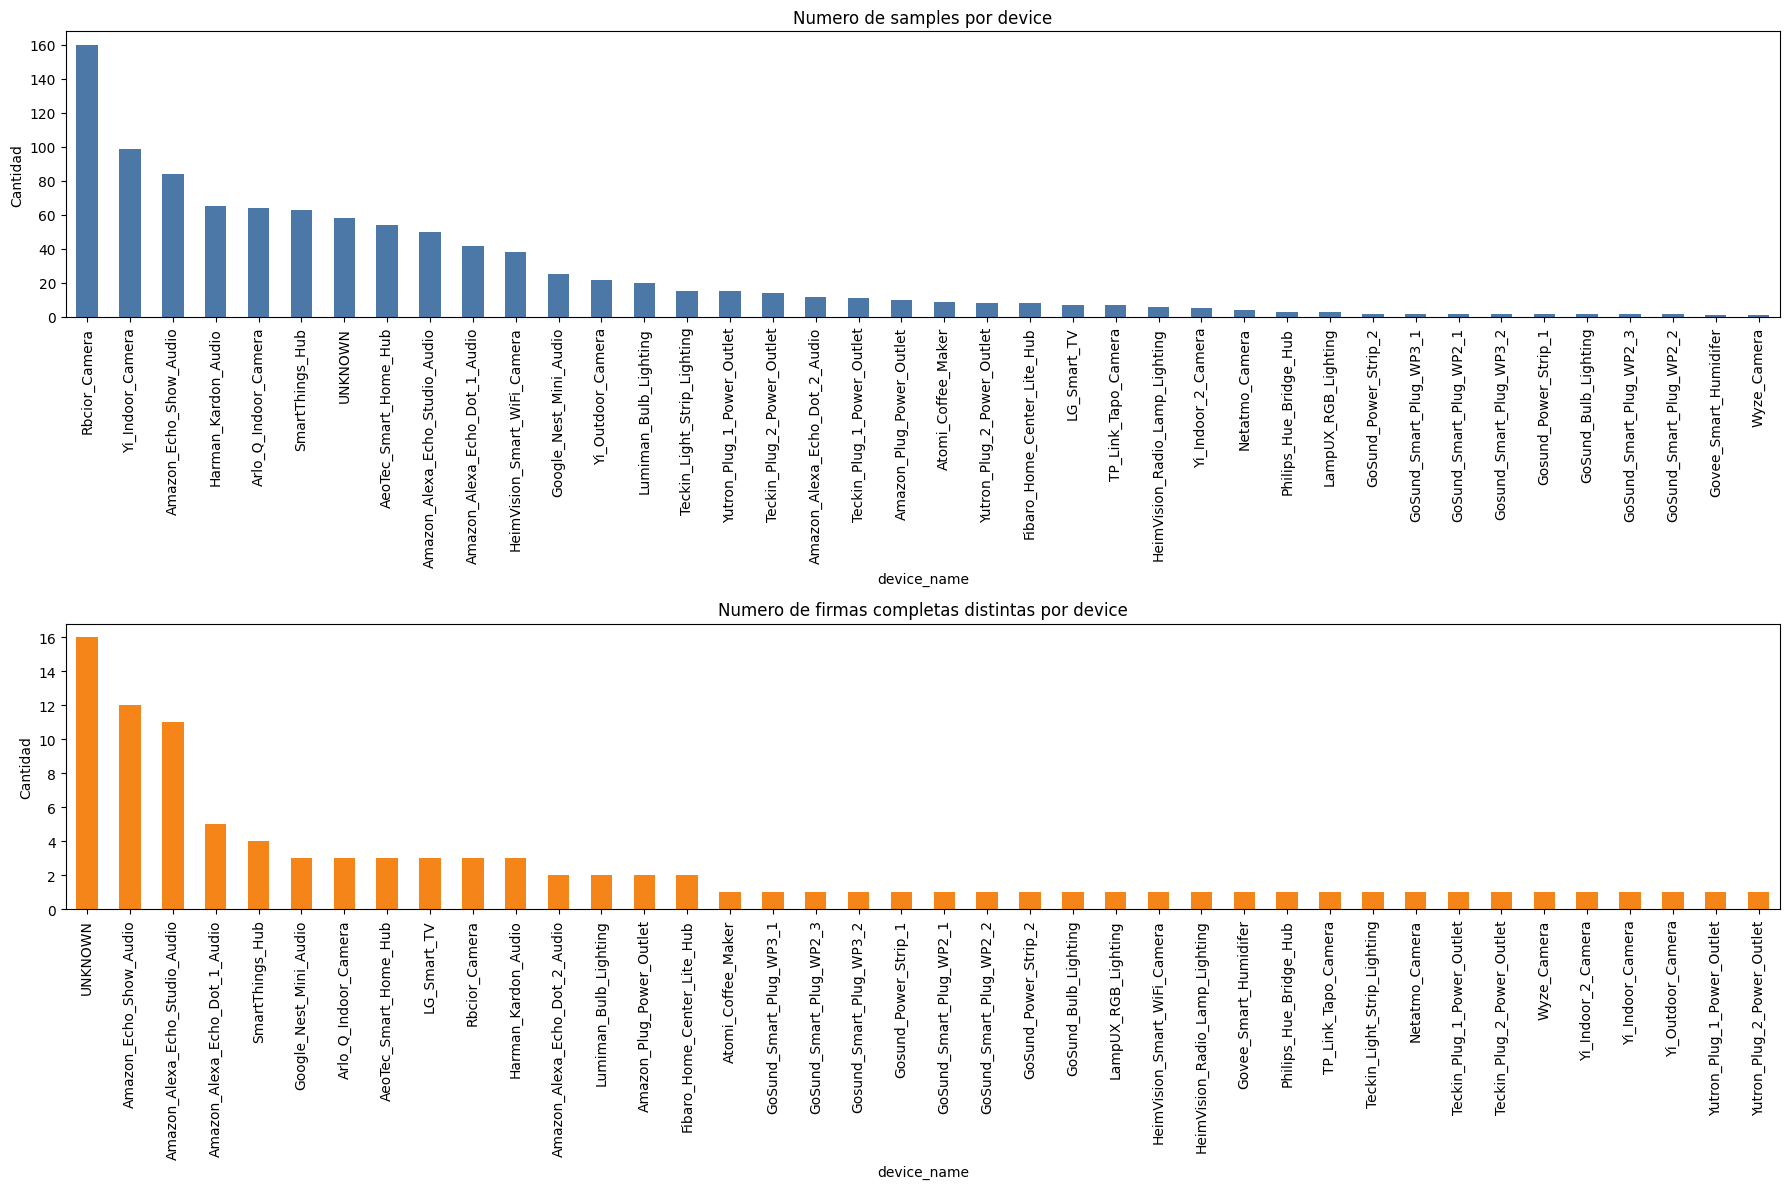

In [2]:
import os

import matplotlib.pyplot as plt

df["signature_bundle"] = (
    df[signature_columns]
    .fillna("")
    .astype(str)
    .agg(" | ".join, axis=1)
)

total_samples = df.groupby("device_name").size().sort_values(ascending=False)
distinct_signatures = df.groupby("device_name")["signature_bundle"].nunique().sort_values(ascending=False)

print("Number of samples per device_name")
print(total_samples.to_string())
print()
print("Number of distinct full-fingerprint bundles per device_name")
print(distinct_signatures.to_string())

fig, axes = plt.subplots(2, 1, figsize=(18, 12))

total_samples.plot(kind="bar", ax=axes[0], color="#4C78A8")
axes[0].set_title("Numero de samples por device")
axes[0].set_xlabel("device_name")
axes[0].set_ylabel("Cantidad")
axes[0].tick_params(axis="x", rotation=90)

distinct_signatures.plot(kind="bar", ax=axes[1], color="#F58518")
axes[1].set_title("Numero de firmas completas distintas por device")
axes[1].set_xlabel("device_name")
axes[1].set_ylabel("Cantidad")
axes[1].tick_params(axis="x", rotation=90)

base_path= r"C:\Users\gemma\Downloads\TFG_GemmaBeatrizVate\3_Results\img"
save_path = rf"{base_path}\rf_full_fingerprints\rf_ja4+ja4s_full_fingerprint\sample_and_signature_counts.pdf"
os.makedirs(os.path.dirname(save_path), exist_ok=True)
plt.tight_layout()
plt.savefig(save_path, format="pdf", bbox_inches="tight")

### 1.2 Model filtering on minimum and maximum samples per device

In [3]:
min_samples_per_device = 3
max_samples_per_device = 60

device_counts = df["device_name"].value_counts()
valid_devices = device_counts[device_counts >= min_samples_per_device].index

df = df[df["device_name"].isin(valid_devices)].copy()

if max_samples_per_device is not None:
    df = (
        df.groupby("device_name", group_keys=False)
        .head(max_samples_per_device)
        .reset_index(drop=True)
    )
else:
    df = df.reset_index(drop=True)

filtered_counts = df["device_name"].value_counts().sort_values(ascending=False)

print("Number of records per device_name after filtering")
print(filtered_counts.to_string())
print()
print(f"Number of devices kept: {len(filtered_counts)}")
print(f"Total number of records after filtering: {len(df)}")

df.head()

Number of records per device_name after filtering
device_name
Rbcior_Camera                     60
SmartThings_Hub                   60
Amazon_Echo_Show_Audio            60
Harman_Kardon_Audio               60
Yi_Indoor_Camera                  60
Arlo_Q_Indoor_Camera              60
UNKNOWN                           58
AeoTec_Smart_Home_Hub             54
Amazon_Alexa_Echo_Studio_Audio    50
Amazon_Alexa_Echo_Dot_1_Audio     42
HeimVision_Smart_WiFi_Camera      38
Google_Nest_Mini_Audio            25
Yi_Outdoor_Camera                 22
Lumiman_Bulb_Lighting             20
Yutron_Plug_1_Power_Outlet        15
Teckin_Light_Strip_Lighting       15
Teckin_Plug_2_Power_Outlet        14
Amazon_Alexa_Echo_Dot_2_Audio     12
Teckin_Plug_1_Power_Outlet        11
Amazon_Plug_Power_Outlet          10
Atomi_Coffee_Maker                 9
Fibaro_Home_Center_Lite_Hub        8
Yutron_Plug_2_Power_Outlet         8
TP_Link_Tapo_Camera                7
LG_Smart_TV                        7
HeimVision_Ra

,device_name,ja4,ja4s,signature_bundle
0,AeoTec_Smart_Home_Hub,t12d2510h1_7415a186c913_0d84c9fec210,t1206h1_c02f_8ec1f1c8cb73,t12d2510h1_7415a186c913_0d84c9fec210 | t1206h1...
1,Rbcior_Camera,t12d040600_39def8a70f78_9b994c9d23f8,t120300_c027_7815a3cc5eb2,t12d040600_39def8a70f78_9b994c9d23f8 | t120300...
2,Rbcior_Camera,t12d040600_39def8a70f78_9b994c9d23f8,t120400_c013_d23d0754cf28,t12d040600_39def8a70f78_9b994c9d23f8 | t120400...
3,Yutron_Plug_1_Power_Outlet,t12i020600_96495e174321_c9df22c671e6,t120300_00ae_468c819633e6,t12i020600_96495e174321_c9df22c671e6 | t120300...
4,Rbcior_Camera,t12d040600_39def8a70f78_9b994c9d23f8,t120400_c013_d23d0754cf28,t12d040600_39def8a70f78_9b994c9d23f8 | t120400...


## 2. Data preprocessing

### 2.1 Feature encoding

The following steps convert the JA4 variables into a representation suitable for multiclass RandomForest classification.

In [4]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

target_column = "device_name"
feature_columns = signature_columns

df_model = df[feature_columns + [target_column]].copy()

for column in feature_columns + [target_column]:
    df_model[column] = (
        df_model[column]
        .fillna("unknown")
        .astype(str)
        .str.strip()
        .str.lower()
    )


### 2.2 Dataset composition

In [5]:
X = df_model[feature_columns].copy()
y = df_model[target_column].copy()

X_train_list, X_test_list = [], []
y_train_list, y_test_list = [], []

# Split: 70% train, 10% val,  20% test
for device in df_model[target_column].unique():
    device_mask = df_model[target_column] == device
    X_device = X[device_mask].reset_index(drop=True)
    y_device = y[device_mask].reset_index(drop=True)

    X_train_device, X_test_device, y_train_device, y_test_device = train_test_split(
        X_device,
        y_device,
        test_size=0.2,
        random_state=535,
        shuffle=True,
    )

    X_train_list.append(X_train_device)
    X_test_list.append(X_test_device)
    y_train_list.append(y_train_device)
    y_test_list.append(y_test_device)

X_train_raw = pd.concat(X_train_list, ignore_index=True)
X_test_raw = pd.concat(X_test_list, ignore_index=True)
y_train_raw = pd.concat(y_train_list, ignore_index=True)
y_test_raw = pd.concat(y_test_list, ignore_index=True)

X_train = pd.get_dummies(
    X_train_raw,
    columns=feature_columns,
    dtype=np.int8,
    dummy_na=False,
    drop_first=False,
    prefix_sep="=",
)
X_test = pd.get_dummies(
    X_test_raw,
    columns=feature_columns,
    dtype=np.int8,
    dummy_na=False,
    drop_first=False,
    prefix_sep="=",
)

union_columns = set(X_train.columns) | set(X_test.columns)
for col in union_columns:
    if col not in X_train.columns:
        X_train[col] = 0
    if col not in X_test.columns:
        X_test[col] = 0

X_train = X_train[sorted(union_columns)]
X_test = X_test[sorted(union_columns)]

label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train_raw)
y_test = label_encoder.transform(y_test_raw)
class_names = label_encoder.classes_

print("\n\n" + "="*80)
print(f"CONFIGURATION: min_samples={min_samples_per_device}, max_samples={max_samples_per_device}")
print("="*80)

print(f"Train size: {len(X_train)}")
print(f"Test size: {len(X_test)}")
print(f"Number of columns after one-hot encoding: {X_train.shape[1]}")
print("First classes:", class_names[:10])



CONFIGURATION: min_samples=3, max_samples=60
Train size: 637
Test size: 169
Number of columns after one-hot encoding: 92
First classes: ['aeotec_smart_home_hub' 'amazon_alexa_echo_dot_1_audio'
 'amazon_alexa_echo_dot_2_audio' 'amazon_alexa_echo_studio_audio'
 'amazon_echo_show_audio' 'amazon_plug_power_outlet'
 'arlo_q_indoor_camera' 'atomi_coffee_maker' 'fibaro_home_center_lite_hub'
 'google_nest_mini_audio']


In [6]:
print("Class distribution in y_train_raw:")
print(y_train_raw.value_counts(normalize=True).sort_index())
print()

print("Class distribution in y_test_raw:")
print(y_test_raw.value_counts(normalize=True).sort_index())

Class distribution in y_train_raw:
device_name
aeotec_smart_home_hub             0.067504
amazon_alexa_echo_dot_1_audio     0.051805
amazon_alexa_echo_dot_2_audio     0.014129
amazon_alexa_echo_studio_audio    0.062794
amazon_echo_show_audio            0.075353
amazon_plug_power_outlet          0.012559
arlo_q_indoor_camera              0.075353
atomi_coffee_maker                0.010989
fibaro_home_center_lite_hub       0.009419
google_nest_mini_audio            0.031397
harman_kardon_audio               0.075353
heimvision_radio_lamp_lighting    0.006279
heimvision_smart_wifi_camera      0.047096
lampux_rgb_lighting               0.003140
lg_smart_tv                       0.007849
lumiman_bulb_lighting             0.025118
netatmo_camera                    0.004710
philips_hue_bridge_hub            0.003140
rbcior_camera                     0.075353
smartthings_hub                   0.075353
teckin_light_strip_lighting       0.018838
teckin_plug_1_power_outlet        0.012559
teckin_

## 3. Model Training
Random Forest hyperparameter tuning with GridSearchCV

In [7]:
import time
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, make_scorer
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [20, 30, None],
    "min_samples_split": [2, 10],
    "min_samples_leaf": [1, 4],
    "max_features": ["sqrt"],
    "class_weight": ["balanced"],
}

rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)
macro_f1_scorer = make_scorer(f1_score, average='macro', zero_division=0)

grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    scoring=macro_f1_scorer,
    cv=5,
    n_jobs=-1,
    verbose=0,
)

print(f"Running GridSearchCV...")
start_time = time.time()
grid_search.fit(X_train, y_train)
elapsed = time.time() - start_time
print(f"GridSearch completed in {elapsed:.1f} sec")

rf_model = grid_search.best_estimator_
print(f"\nBest GridSearch parameters:")
for param, value in grid_search.best_params_.items():
    print(f"  - {param}: {value}")

Running GridSearchCV...


C:\Users\gemma\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


GridSearch completed in 26.9 sec

Best GridSearch parameters:
  - class_weight: balanced
  - max_depth: 30
  - max_features: sqrt
  - min_samples_leaf: 1
  - min_samples_split: 2
  - n_estimators: 200


## 4. Evaluation and Results

This section evaluates the final model on the test split, including the confusion matrix and the precision, recall, and F1-score values reported by sklearn.metrics.classification_report().

In [8]:
import time
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    top_k_accuracy_score,
    classification_report,
)

# Predictions and probabilities for each split
train_predictions = rf_model.predict(X_train)
train_probabilities = rf_model.predict_proba(X_train)

test_predictions = rf_model.predict(X_test)
test_probabilities = rf_model.predict_proba(X_test)

# Accuracy
train_accuracy = accuracy_score(y_train, train_predictions)
test_accuracy = accuracy_score(y_test, test_predictions)

# Precision
train_precision = precision_score(y_train, train_predictions, average='macro', zero_division=0)
test_precision = precision_score(y_test, test_predictions, average='macro', zero_division=0)

# Recall
train_recall = recall_score(y_train, train_predictions, average='macro', zero_division=0)
test_recall = recall_score(y_test, test_predictions, average='macro', zero_division=0)

# Macro F1 
train_f1_macro = f1_score(y_train, train_predictions, average='macro', zero_division=0)
test_f1_macro = f1_score(y_test, test_predictions, average='macro', zero_division=0)

# Top-k accuracy
top_3_k = min(3, len(class_names))
top_5_k = min(5, len(class_names))

if len(class_names) <= top_3_k:
    test_top_3_accuracy = 1.0
else:
    test_top_3_accuracy = top_k_accuracy_score(
        y_test, test_probabilities, k=top_3_k, labels=np.arange(len(class_names))
    )

if len(class_names) <= top_5_k:
    test_top_5_accuracy = 1.0
else:
    test_top_5_accuracy = top_k_accuracy_score(
        y_test, test_probabilities, k=top_5_k, labels=np.arange(len(class_names))
    )

# Per-sample prediction timing
prediction_times = []
for sample_index in range(len(X_test)):
    sample_features = X_test.iloc[[sample_index]]
    start_time = time.perf_counter()
    rf_model.predict_proba(sample_features)
    elapsed_time = time.perf_counter() - start_time
    prediction_times.append(elapsed_time)

average_prediction_time = float(np.mean(prediction_times))
all_labels = np.arange(len(class_names))

print("="*80)
print("GENERAL RESULTS")
print("="*80)
print("\nAccuracy:")
print(f"  - Train: {train_accuracy:.4f}")
print(f"  - Test:  {test_accuracy:.4f}")

print("\nPrecision:")
print(f"  - Train: {train_precision:.4f}")
print(f"  - Test:  {test_precision:.4f}")

print("\nRecall:")
print(f"  - Train: {train_recall:.4f}")
print(f"  - Test:  {test_recall:.4f}")

print("\nMacro F1 Score:")
print(f"  - Train: {train_f1_macro:.4f}")
print(f"  - Test:  {test_f1_macro:.4f}")

print("\nTop-k accuracy on the test split:")
print(f"  - top_{top_3_k}_accuracy: {test_top_3_accuracy:.4f}")
print(f"  - top_{top_5_k}_accuracy: {test_top_5_accuracy:.4f}")

print(f"\nAverage prediction time: {average_prediction_time:.6f} s ({average_prediction_time * 1000:.3f} ms)")

print("\n" + "="*80)
print("CLASSIFICATION REPORT - TEST")
print("="*80)
print(
    classification_report(
        y_test,
        test_predictions,
        labels=all_labels,
        target_names=class_names,
        zero_division=0,
    )
)

GENERAL RESULTS

Accuracy:
  - Train: 0.8053
  - Test:  0.7929

Precision:
  - Train: 0.7130
  - Test:  0.7147

Recall:
  - Train: 0.7474
  - Test:  0.7169

Macro F1 Score:
  - Train: 0.7065
  - Test:  0.6822

Top-k accuracy on the test split:
  - top_3_accuracy: 0.9467
  - top_5_accuracy: 0.9882

Average prediction time: 0.053593 s (53.593 ms)

CLASSIFICATION REPORT - TEST
                                precision    recall  f1-score   support

         aeotec_smart_home_hub       0.50      1.00      0.67        11
 amazon_alexa_echo_dot_1_audio       1.00      0.89      0.94         9
 amazon_alexa_echo_dot_2_audio       0.50      1.00      0.67         3
amazon_alexa_echo_studio_audio       0.78      0.70      0.74        10
        amazon_echo_show_audio       0.91      0.83      0.87        12
      amazon_plug_power_outlet       1.00      1.00      1.00         2
          arlo_q_indoor_camera       1.00      1.00      1.00        12
            atomi_coffee_maker       0.00     

### Confusion matrix

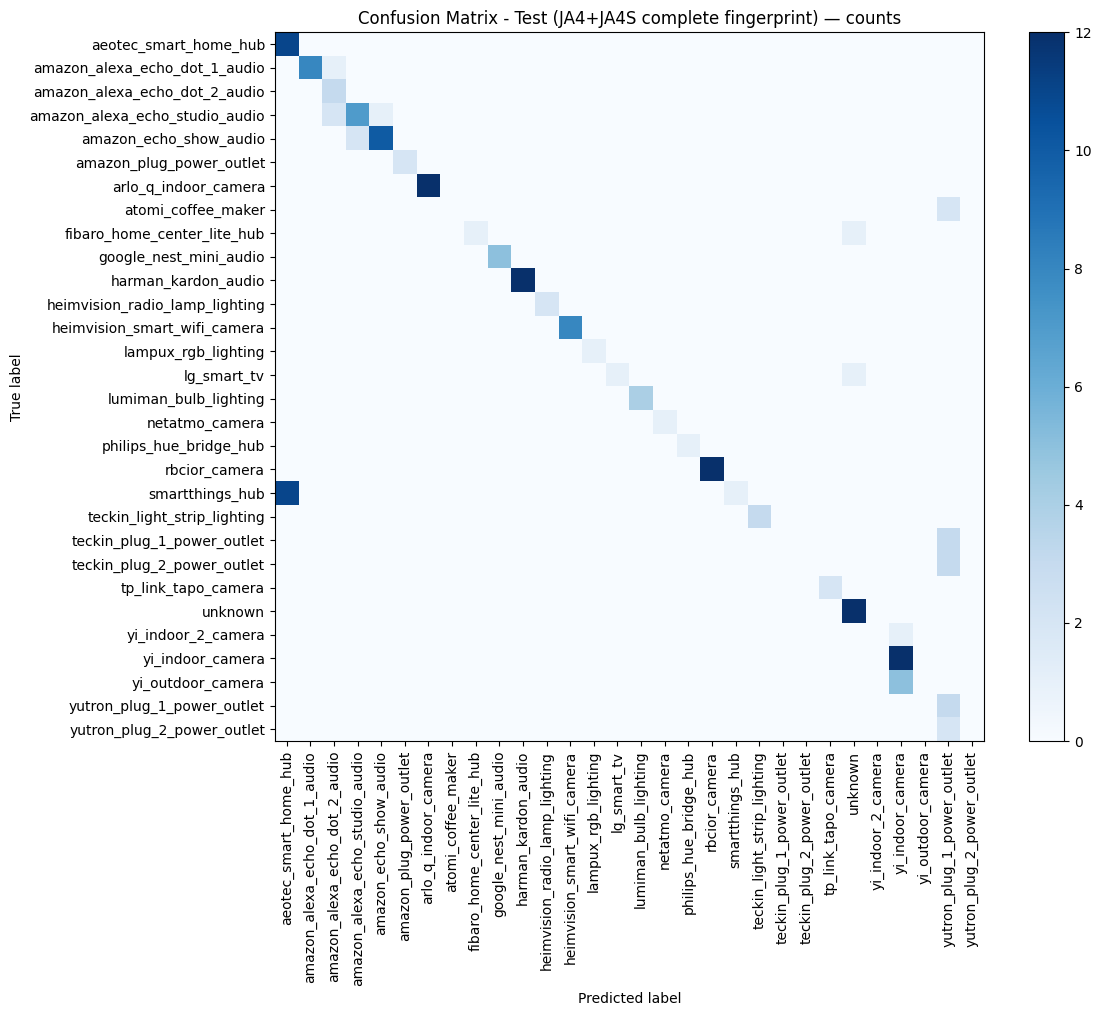

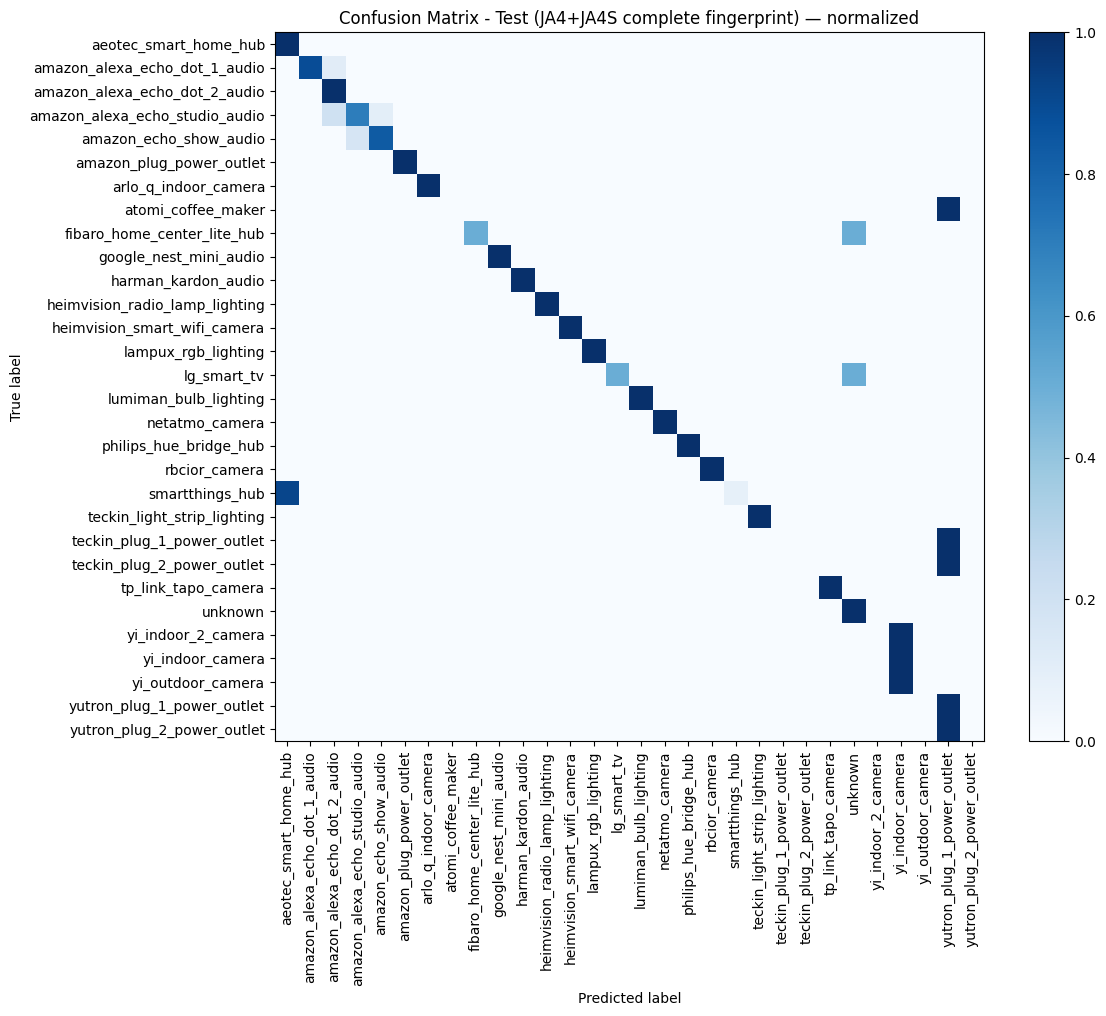

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
import os

feature_set_label = "JA4+JA4S complete fingerprint"
base_path = r"C:\Users\gemma\Downloads\TFG_GemmaBeatrizVate\3_Results\img"
out_dir = rf"{base_path}\rf_full_fingerprints\rf_ja4+ja4s_full_fingerprint"
os.makedirs(out_dir, exist_ok=True)

# Confusion matrix (counts)
cm = confusion_matrix(y_test, test_predictions, labels=np.arange(len(class_names)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(12, 10))
disp.plot(cmap="Blues", ax=ax, colorbar=True, include_values=False)
ax.set_title(f"Confusion Matrix - Test ({feature_set_label}) — counts")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "confusion_matrix_counts.pdf"), format="pdf", bbox_inches="tight")
plt.show()

# Confusion matrix (normalized by true class)
denom = cm.sum(axis=1)[:, np.newaxis]
denom[denom == 0] = 1
cm_norm = cm.astype(float) / denom
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(12, 10))
disp_norm.plot(cmap="Blues", ax=ax, colorbar=True, include_values=False)
ax.set_title(f"Confusion Matrix - Test ({feature_set_label}) — normalized")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "confusion_matrix_normalized.pdf"), format="pdf", bbox_inches="tight")
plt.show()

### 4.1 Final Evaluation and Metrics Summary

This section summarizes accuracy, macro metrics, top-k accuracy, prediction time, and the confusion matrix for the final Random Forest model.

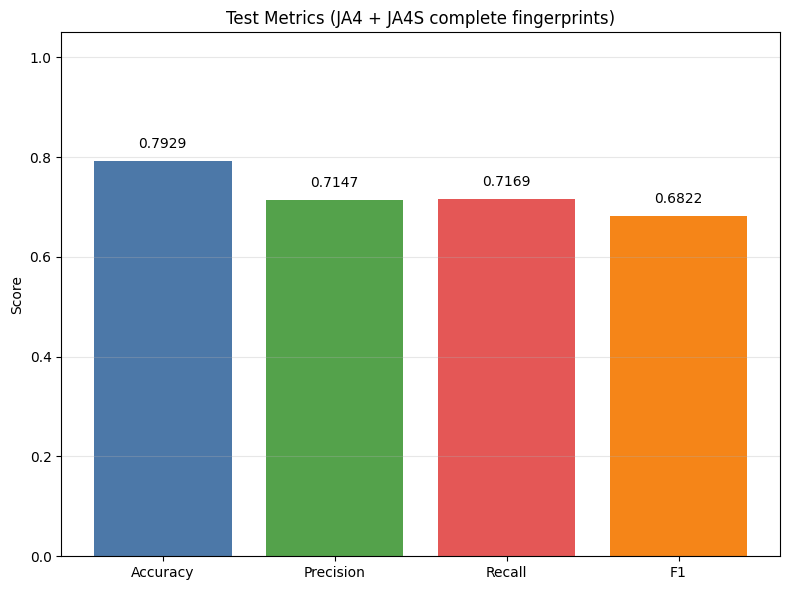

In [10]:
import matplotlib.pyplot as plt

feature_set_label = "JA4 + JA4S complete fingerprints"

metrics = ["Accuracy", "Precision", "Recall", "F1"]
values = [test_accuracy, test_precision, test_recall, test_f1_macro]

top_k_labels = ["Top-1", "Top-3", "Top-5"]
top_k_values = [test_accuracy, test_top_3_accuracy, test_top_5_accuracy]

plt.figure(figsize=(8, 6))
bars = plt.bar(metrics, values, color=["#4C78A8", "#54A24B", "#E45756", "#F58518"])
plt.title(f"Test Metrics ({feature_set_label})")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.grid(axis="y", alpha=0.3)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 0.02, f"{yval:.4f}", ha="center", va="bottom", fontsize=10)

base_path= r"C:\Users\gemma\Downloads\TFG_GemmaBeatrizVate\3_Results\img"
save_path = rf"{base_path}\rf_full_fingerprints\rf_ja4+ja4s_full_fingerprint\test_metrics.pdf"
os.makedirs(os.path.dirname(save_path), exist_ok=True)
plt.tight_layout()
plt.savefig(save_path, format="pdf", bbox_inches="tight")


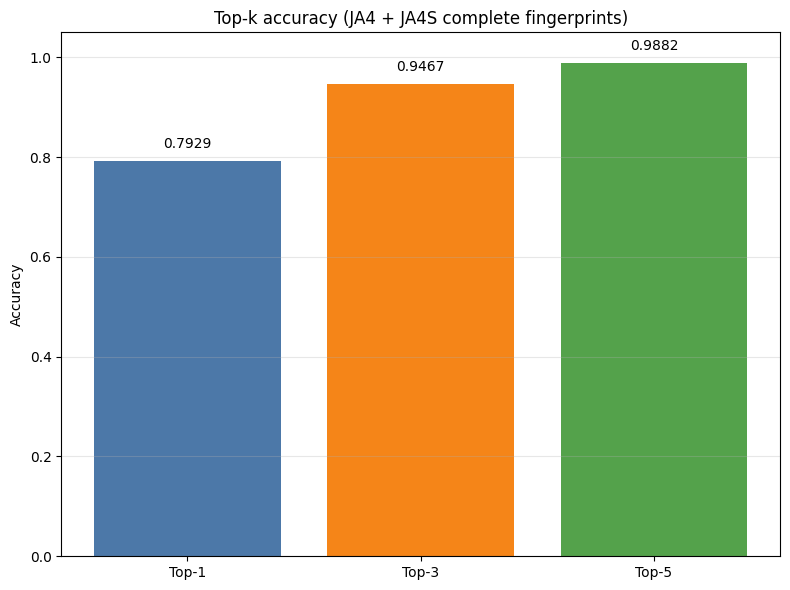

In [11]:

plt.figure(figsize=(8, 6))
bars = plt.bar(top_k_labels, top_k_values, color=["#4C78A8", "#F58518", "#54A24B"])
plt.title(f"Top-k accuracy ({feature_set_label})")
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)
plt.grid(axis="y", alpha=0.3)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 0.02, f"{yval:.4f}", ha="center", va="bottom", fontsize=10)

base_path= r"C:\Users\gemma\Downloads\TFG_GemmaBeatrizVate\3_Results\img"
save_path = rf"{base_path}\rf_full_fingerprints\rf_ja4+ja4s_full_fingerprint\top_k_accuracy.pdf"
os.makedirs(os.path.dirname(save_path), exist_ok=True)
plt.tight_layout()
plt.savefig(save_path, format="pdf", bbox_inches="tight")

In [12]:
metrics_summary = {
    "test_accuracy": float(test_accuracy),
    "test_macro_precision": float(test_precision),
    "test_macro_recall": float(test_recall),
    "test_macro_f1": float(test_f1_macro),
    f"top_{top_3_k}_accuracy": float(test_top_3_accuracy),
    f"top_{top_5_k}_accuracy": float(test_top_5_accuracy),
    "avg_prediction_time_ms": float(average_prediction_time * 1000),
}

print("=" * 80)
print("FINAL METRICS SUMMARY")
print("=" * 80)
for metric_name, metric_value in metrics_summary.items():
    print(f"- {metric_name}: {metric_value:.4f}")

print()
print("Best parameters used in the final model:")
for param, value in grid_search.best_params_.items():
    print(f"  - {param}: {value}")

FINAL METRICS SUMMARY
- test_accuracy: 0.7929
- test_macro_precision: 0.7147
- test_macro_recall: 0.7169
- test_macro_f1: 0.6822
- top_3_accuracy: 0.9467
- top_5_accuracy: 0.9882
- avg_prediction_time_ms: 53.5927

Best parameters used in the final model:
  - class_weight: balanced
  - max_depth: 30
  - max_features: sqrt
  - min_samples_leaf: 1
  - min_samples_split: 2
  - n_estimators: 200


### 4.2 Save the Trained Model

In [13]:
import joblib
import json
from pathlib import Path

project_root = Path(r"C:\Users\gemma\Downloads\TFG_GemmaBeatrizVate")
if not project_root.exists():
    project_root = Path("/mnt/d/TFG_GemmaBeatrizVate")

model_dir = project_root / "3_Results" / "models" / "rf_ja4_ja4s_full_fingerprint"
model_dir.mkdir(parents=True, exist_ok=True)

model_path = model_dir / "model.joblib"
joblib.dump(rf_model, model_path)

artifacts = {
    "experiment": "rf_ja4_ja4s_full_fingerprint",
    "signature_columns": signature_columns,
    "class_names": class_names.tolist(),
    "best_params": grid_search.best_params_,
    "metrics_summary": metrics_summary,
    "train_size": int(len(X_train)),
    "test_size": int(len(X_test)),
    "min_samples_per_device": int(min_samples_per_device),
    "max_samples_per_device": None if max_samples_per_device is None else int(max_samples_per_device),
}

artifacts_path = model_dir / "artifacts.json"
with artifacts_path.open("w", encoding="utf-8") as file:
    json.dump(artifacts, file, indent=2)

print(f"Model saved to: {model_path}")
print(f"Artifacts saved to: {artifacts_path}")

Model saved to: C:\Users\gemma\Downloads\TFG_GemmaBeatrizVate\3_Results\models\rf_ja4_ja4s_full_fingerprint\model.joblib
Artifacts saved to: C:\Users\gemma\Downloads\TFG_GemmaBeatrizVate\3_Results\models\rf_ja4_ja4s_full_fingerprint\artifacts.json
